# Spotify Dataset EDA -- Candidate/Approval Characteristics

PJR verification is very slow on the Spotify datasets. This notebook
investigates why, focusing on the two things that directly drive
verification cost: how many candidates each round has, and how large
approval sets are (since `verify_pjr.find_pjr_violations` rebuilds a
`set()` per voter per round for *every* one of the `2^n - 1` voter
groups -- large approval sets multiplied across an exponential number of
groups is expensive).

Key wrinkle: missing voters are backfilled to "approve every candidate
that round" (`tsoi_to_json._fill_missing_voters`), which can make
approval sets look far larger than voters' genuine preferences. This
notebook parses the **raw `.tsoi` files directly** (via `tsoi_to_dict`)
to recover genuine, pre-backfill votes, and compares them against the
**post-backfill data** (via `load_jsonl_dataset`) that verification
actually processes -- so we can see how much of the cost is genuine
preference data vs. backfill inflation, and whether trimming
never-approved candidates would help.

Assumes this notebook is launched with the repository root as the
working directory (e.g. `task jupyter`, or `jupyter lab` run from the
repo root).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(marker: str = "pyproject.toml") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' in any parent of {Path.cwd()}")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from src.data_transformation.tsoi_to_json import tsoi_to_dict  # noqa: E402
from src.real_data_tools.run_natural_experiment import load_jsonl_dataset  # noqa: E402

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load raw (pre-backfill) and post-backfill data for every Spotify dataset

For each dataset: parse every `.tsoi` file directly (genuine, per-round
votes as they actually were cast) and load the converted JSONL (the
backfilled version experiments/verification actually use). Both are
walked in the same chronological order, so round indices line up.

In [2]:
SPOTIFY_DATASETS = ["daily_tsoi", "viral_daily_tsoi", "viral_weekly_tsoi", "weekly_tsoi"]

round_rows = []
voter_round_rows = []

for name in SPOTIFY_DATASETS:
    raw_dir = REPO_ROOT / "real_data" / "spotify" / name
    jsonl_path = REPO_ROOT / "real_data" / "json_datasets" / f"spotify-{name}"

    raw_rounds = [tsoi_to_dict(p) for p in sorted(raw_dir.iterdir())]
    loaded = load_jsonl_dataset(jsonl_path)
    assert loaded is not None, f"failed to load {jsonl_path}"
    _, instance = loaded
    assert len(raw_rounds) == len(instance), f"round count mismatch for {name}"

    for t, (raw_round, profile) in enumerate(zip(raw_rounds, instance, strict=True)):
        real_voters = raw_round["voters"]
        cands = raw_round["cands"]
        real_voters_set = set(real_voters)

        genuinely_approved = set()
        for v in real_voters:
            genuinely_approved.update(raw_round["approval_sets"][v])
        num_zero_approval = len(cands) - len(genuinely_approved)

        round_rows.append(
            {
                "dataset": name,
                "round": t,
                "num_candidates": len(cands),
                "num_real_voters": len(real_voters),
                "num_master_voters": len(profile.voters),
                "num_backfilled_voters": len(profile.voters) - len(real_voters),
                "num_candidates_zero_genuine_approval": num_zero_approval,
                "pct_candidates_zero_genuine_approval": num_zero_approval / len(cands),
            }
        )

        for voter in profile.voters:
            voter_round_rows.append(
                {
                    "dataset": name,
                    "round": t,
                    "voter": voter,
                    "approval_size": len(profile.approval_sets[voter]),
                    "is_backfilled": voter not in real_voters_set,
                }
            )

round_df = pd.DataFrame(round_rows)
voter_round_df = pd.DataFrame(voter_round_rows)

print(f"round_df:       {round_df.shape[0]:>6} rows (one per dataset-round)")
print(f"voter_round_df: {voter_round_df.shape[0]:>6} rows (one per dataset-round-voter)")
round_df.head()

round_df:         2419 rows (one per dataset-round)
voter_round_df: 148313 rows (one per dataset-round-voter)


,dataset,round,num_candidates,num_real_voters,num_master_voters,num_backfilled_voters,num_candidates_zero_genuine_approval,pct_candidates_zero_genuine_approval
0,daily_tsoi,0,2361,57,61,4,0,0.0
1,daily_tsoi,1,2146,57,61,4,0,0.0
2,daily_tsoi,2,2131,57,61,4,0,0.0
3,daily_tsoi,3,2161,57,61,4,0,0.0
4,daily_tsoi,4,2228,57,61,4,0,0.0


## Average approvals per voter, over rounds

Post-backfill (what verification actually processes) vs. genuine-only
(excluding backfilled "approve everything" votes) -- the gap between
them is exactly the backfill inflation effect.

In [3]:
approval_summary = (
    voter_round_df.groupby(["dataset", "is_backfilled"])["approval_size"]
    .mean()
    .unstack("is_backfilled")
    .rename(columns={False: "avg_genuine_approval_size", True: "avg_backfilled_approval_size"})
)
approval_summary["avg_approval_size_overall"] = voter_round_df.groupby("dataset")[
    "approval_size"
].mean()
approval_summary

is_backfilled,avg_genuine_approval_size,avg_backfilled_approval_size,avg_approval_size_overall
dataset,,,
daily_tsoi,180.401219,2982.534545,397.225491
viral_daily_tsoi,49.857716,1206.519975,78.174537
viral_weekly_tsoi,49.658405,1206.850416,93.173646
weekly_tsoi,198.446500,2845.668380,305.982978


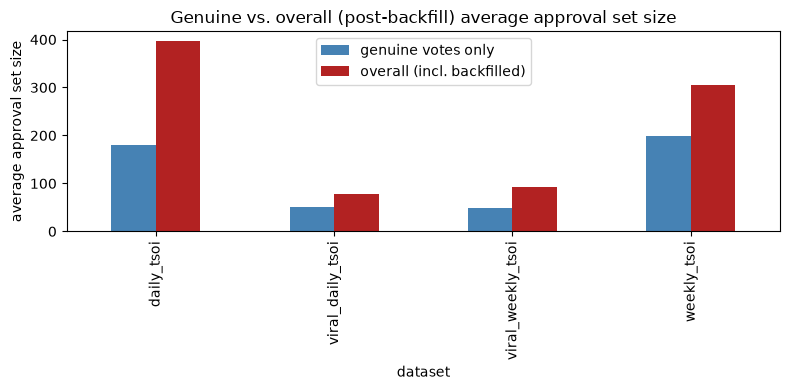

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
approval_summary[["avg_genuine_approval_size", "avg_approval_size_overall"]].plot(
    kind="bar", ax=ax, color=["steelblue", "firebrick"]
)
ax.set_ylabel("average approval set size")
ax.set_title("Genuine vs. overall (post-backfill) average approval set size")
ax.legend(["genuine votes only", "overall (incl. backfilled)"])
fig.tight_layout()

## How many candidates are approved by no one?

For each round, "approved by no one" means excluded from every *genuine*
vote that round (a candidate can only show up with zero total approvals
in the post-backfill data if there were no backfilled voters at all that
round, since a backfilled voter approves everything by construction --
so this has to be measured against genuine votes, not the post-backfill
data).

In [5]:
zero_approval_summary = round_df.groupby("dataset").agg(
    avg_num_candidates=("num_candidates", "mean"),
    avg_num_candidates_zero_genuine_approval=("num_candidates_zero_genuine_approval", "mean"),
    avg_pct_candidates_zero_genuine_approval=("pct_candidates_zero_genuine_approval", "mean"),
    avg_backfilled_voters_per_round=("num_backfilled_voters", "mean"),
    avg_master_voters=("num_master_voters", "mean"),
)
zero_approval_summary

,avg_num_candidates,avg_num_candidates_zero_genuine_approval,avg_pct_candidates_zero_genuine_approval,avg_backfilled_voters_per_round,avg_master_voters
dataset,,,,,
daily_tsoi,3116.246937,0.0,0.0,4.720075,61.0
viral_daily_tsoi,1119.295455,0.0,0.0,1.493371,61.0
viral_weekly_tsoi,1168.753333,0.0,0.0,2.406667,64.0
weekly_tsoi,3248.565789,0.0,0.0,2.559211,63.0


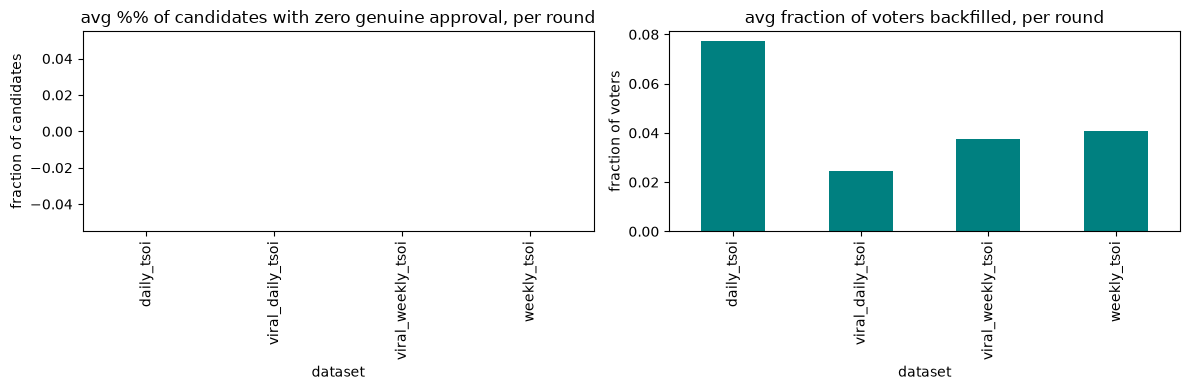

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

zero_approval_summary["avg_pct_candidates_zero_genuine_approval"].plot(
    kind="bar", ax=axes[0], color="darkorange"
)
axes[0].set_title("avg %% of candidates with zero genuine approval, per round")
axes[0].set_ylabel("fraction of candidates")

backfill_fraction = (
    zero_approval_summary["avg_backfilled_voters_per_round"]
    / zero_approval_summary["avg_master_voters"]
)
backfill_fraction.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("avg fraction of voters backfilled, per round")
axes[1].set_ylabel("fraction of voters")
fig.tight_layout()

## Candidate count and approval size over time (spotify-daily)

The dataset with by far the most rounds (T=1061) and the one that's been
slowest to verify -- worth a closer, round-by-round look.

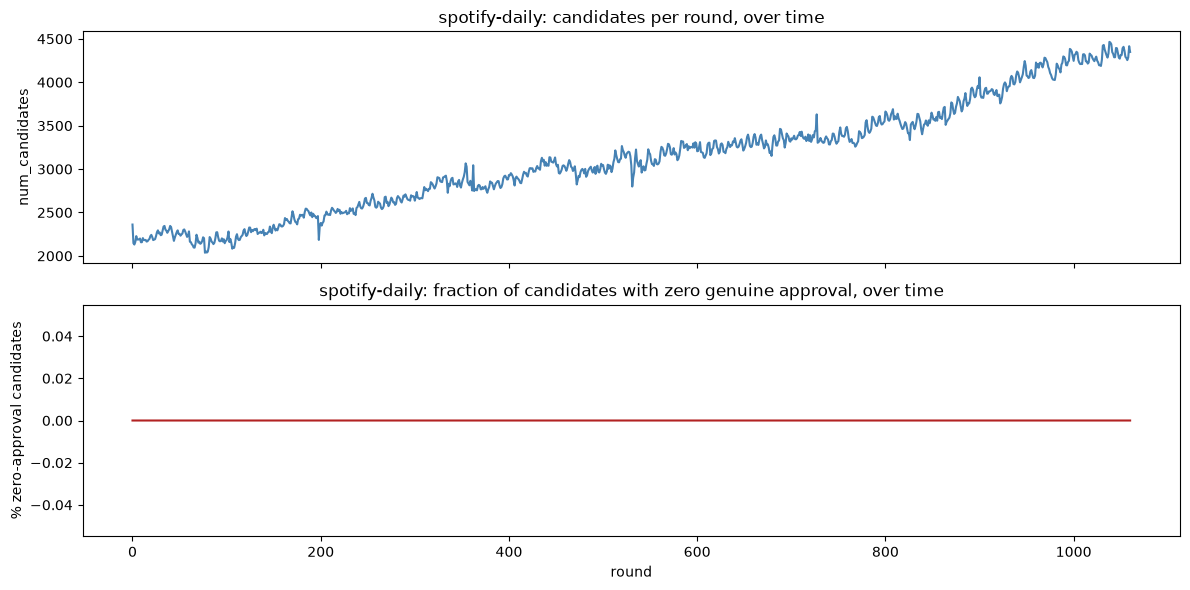

In [7]:
daily = round_df[round_df["dataset"] == "daily_tsoi"].set_index("round")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily["num_candidates"].plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("num_candidates")
axes[0].set_title("spotify-daily: candidates per round, over time")

daily["pct_candidates_zero_genuine_approval"].plot(ax=axes[1], color="firebrick")
axes[1].set_ylabel("% zero-approval candidates")
axes[1].set_title("spotify-daily: fraction of candidates with zero genuine approval, over time")
axes[1].set_xlabel("round")
fig.tight_layout()

## Projected impact of trimming never-approved candidates

Simulates removing, from each round, every candidate with zero genuine
approval that round. Since backfilled voters approve *all* candidates,
their approval set would shrink to the trimmed candidate count -- this
estimates how much smaller the total approval-list "weight" (summed
approval-set size across every voter and round, a rough proxy for
verification cost, since that's exactly what gets rebuilt into a `set()`
per voter per round per group) would become.

In [8]:
current_weight = voter_round_df.groupby("dataset")["approval_size"].sum()

# after trimming: genuine voters' approval sizes are unchanged (they never
# approved the removed candidates anyway); backfilled voters' approval size
# becomes the trimmed candidate count for that round.
trimmed_cand_count = round_df["num_candidates"] - round_df["num_candidates_zero_genuine_approval"]
round_df_trimmed = round_df.assign(trimmed_num_candidates=trimmed_cand_count)

genuine_weight = (
    voter_round_df[~voter_round_df["is_backfilled"]].groupby("dataset")["approval_size"].sum()
)
backfilled_weight_trimmed = (
    round_df_trimmed.assign(
        backfilled_weight=lambda df: df["num_backfilled_voters"] * df["trimmed_num_candidates"]
    )
    .groupby("dataset")["backfilled_weight"]
    .sum()
)

trimmed_weight = genuine_weight + backfilled_weight_trimmed

impact = pd.DataFrame(
    {
        "current_total_approval_weight": current_weight,
        "projected_total_approval_weight": trimmed_weight,
    }
)
impact["projected_reduction"] = 1 - impact["projected_total_approval_weight"] / impact[
    "current_total_approval_weight"
]
impact

,current_total_approval_weight,projected_total_approval_weight,projected_reduction
dataset,,,
daily_tsoi,25708831,25708831,0.0
viral_daily_tsoi,5035691,5035691,0.0
viral_weekly_tsoi,894467,894467,0.0
weekly_tsoi,2930093,2930093,0.0


## Summary

- **Backfill dominates approval-set size on the Spotify datasets**: the
  gap between "genuine" and "overall" average approval size above shows
  how much of what verification processes is voters who didn't
  participate that round being marked as approving everything, rather
  than genuine preference.
- **Trimming never-approved candidates mainly helps by shrinking
  backfilled voters' approval sets** (since a backfilled voter approves
  every remaining candidate) -- the projected reduction above is a rough
  lower bound on potential verification speedup from this change alone
  (it doesn't account for the fact that verification cost scales with
  more than just total approval-list length, e.g. group enumeration is
  still `2^n` regardless).
- If the projected reduction is large, a cheap next step: filter each
  round's candidate list down to candidates with at least one genuine
  approval before running the experiment/verification pipeline on
  Spotify data, rather than changing the verification algorithm itself.